In [1]:
import os
import pandas as pd
from torchinfo import summary
import shutil
from sklearn.model_selection import train_test_split
import glob
import torch
import random
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import seaborn as sns
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import cv2
from PIL import Image
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import ConcatDataset, Dataset

In [2]:
BASE = "/kaggle/input/breast-lesion-usg/BrEaST-Lesions_USG/BrEaST-Lesions_USG-images_and_masks"
CLINICAL_FILE = "/kaggle/input/breast-lesion-usg/BrEaST-Lesions-USG.xlsx"

OUT_BASE = "/kaggle/working/breast_usg_classification"
IMG_OUT = os.path.join(OUT_BASE, "images")

os.makedirs(IMG_OUT, exist_ok=True)

df = pd.read_excel(CLINICAL_FILE)

# Keep only benign and malignant
df = df[df["Classification"].isin(["benign", "malignant"])]

# Copy images into class folders
for _, row in df.iterrows():

    img_name = str(row["Image_filename"]).strip()
    label = str(row["Classification"]).strip()

    # Create class folder
    class_folder = os.path.join(IMG_OUT, label)
    os.makedirs(class_folder, exist_ok=True)

    # Source image
    img_src = os.path.join(BASE, img_name)

    # Copy image
    if os.path.exists(img_src):
        shutil.copy(img_src, os.path.join(class_folder, img_name))
    else:
        print("Missing image:", img_src)

benign_imgs = glob.glob(os.path.join(IMG_OUT, "benign", "*"))
malignant_imgs = glob.glob(os.path.join(IMG_OUT, "malignant", "*"))

print("Total benign:",len(benign_imgs))
print("Total malignant:",len(malignant_imgs))



Total benign: 154
Total malignant: 98


In [3]:
orig_dataset = datasets.ImageFolder(root=IMG_OUT)
print("Original dataset size:", len(orig_dataset))

targets = np.array(orig_dataset.targets)
num_classes = len(orig_dataset.classes)
total_size = len(orig_dataset)
 
y = [label for _, label in orig_dataset.imgs]  # class labels

train_idx, temp_idx = train_test_split(
    np.arange(total_size), 
    test_size=0.3, 
    stratify=y, 
    shuffle=True,
    random_state=None  # random every run
)

val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.75, 
    stratify=[y[i] for i in temp_idx],
    shuffle=True,
    random_state=None
)

train_dataset = Subset(orig_dataset, train_idx)
val_dataset   = Subset(orig_dataset, val_idx)
test_dataset  = Subset(orig_dataset, test_idx)

Original dataset size: 252


In [4]:
tmp_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]   # PIL image + label
        img = self.transform(img)       # apply ToTensor()
        return img, label

train_temp = TransformSubset(train_dataset, tmp_transform)

loader = DataLoader(train_temp, batch_size=32, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

for images, _ in loader:
    batch_samples = images.size(0)

    images = images.view(batch_samples, 3, -1)   # B × C × (H*W)

    mean += images.mean(2).sum(0)
    std  += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std  /= total_images

print("Calculated Mean: ", mean)
print("Calculated Std:  ", std)

Calculated Mean:  tensor([0.2565, 0.2627, 0.2732])
Calculated Std:   tensor([0.1279, 0.1305, 0.1346])


In [5]:
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# val_dataset = Subset(
#     datasets.ImageFolder(IMG_OUT, transform=val_test_transform),
#     val_idx
# )

test_dataset = Subset(
    datasets.ImageFolder(IMG_OUT, transform=val_test_transform),
    test_idx
)


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    # transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    # transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    # transforms.RandomAutocontrast(p=0.5),
    # transforms.RandomEqualize(p=0.5),
    transforms.RandomRotation(10),
    # transforms.Lambda(lambda img: median_filter(img, ksize=3)),
    # transforms.Lambda(lambda img: apply_CLAHE(img)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


In [7]:
BATCH_SIZE = 16

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Train samples: 176
Val samples: 19
Test samples: 57


In [8]:
# Get the number of images per class
class_counts = {}
for class_folder in os.listdir(IMG_OUT):
    class_path = os.path.join(IMG_OUT, class_folder)
    if os.path.isdir(class_path):
        class_counts[class_folder] = len(os.listdir(class_path))

# Convert keys and values to numpy arrays to avoid seaborn warning
classes = np.array(list(class_counts.keys()))
counts = np.array(list(class_counts.values()))

# Print the counts
print("Class Counts:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

# Calculate class weights dynamically using inverse frequency method
total_samples = counts.sum()
num_classes = len(class_counts)

class_weights = {}
for cls, count in class_counts.items():
    class_weights[cls] = total_samples / (num_classes * count)

print("\nCalculated Class Weights:")
for cls, weight in class_weights.items():
    print(f"{cls}: {weight:.4f}")


# Convert class weights to PyTorch tensor (ordered by classes)
weights_list = [class_weights[cls] for cls in orig_dataset.classes]

weights_tensor = torch.tensor(weights_list, dtype=torch.float32)

print("\nClass weights tensor:")
print(weights_tensor)

class_names=orig_dataset.classes
print(class_names)

Class Counts:
malignant: 98
benign: 154

Calculated Class Weights:
malignant: 1.2857
benign: 0.8182

Class weights tensor:
tensor([0.8182, 1.2857])
['benign', 'malignant']


In [9]:
class AdaptiveDb4DWT(nn.Module):
    def __init__(self, init_scale=1.0):
        super().__init__()

        # ---- db4 coefficients ----
        h0 = torch.tensor([
            0.4829629131445341,
            0.8365163037378079,
            0.2241438680420134,
           -0.1294095225512604
        ])

        h1 = torch.tensor([
           -0.1294095225512604,
           -0.2241438680420134,
            0.8365163037378079,
           -0.4829629131445341
        ])

        # ---- 2D separable filters ----
        ll = torch.outer(h0, h0)
        lh = torch.outer(h0, h1)
        hl = torch.outer(h1, h0)
        hh = torch.outer(h1, h1)

        filters = torch.stack([ll, lh, hl, hh])  # (4, k, k)
        self.register_buffer("filters", filters.unsqueeze(1))  # (4,1,k,k)

        self.band_scale = nn.Parameter(torch.ones(1, 4, 1, 1))

    def forward(self, x):
        B, C, H, W = x.shape

        # Repeat db4 filters for group convolution
        weight = self.filters.repeat(C, 1, 1, 1)

        # Padding = filter_size - 2  (for proper alignment)
        pad = self.filters.shape[-1] - 2

        x = F.conv2d(x, weight, stride=2, padding=pad, groups=C)
        _, _, H2, W2 = x.shape
        x = x.view(B, C, 4, H2, W2)

        scale = torch.sigmoid(self.band_scale)
        x = x * scale
        
        return x.view(B, 4 * C, H2, W2)


In [10]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_ch, in_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=in_ch,
            bias=False
        )

        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)

        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.act(x)


class XceptionBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, reps=2):
        super().__init__()

        layers = []
        ch = in_ch
        for _ in range(reps):
            layers.append(SeparableConv2d(ch, out_ch))
            ch = out_ch

        self.block = nn.Sequential(*layers)

        self.skip = None
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

        self.pool = nn.MaxPool2d(3, stride=stride, padding=1) if stride != 1 else nn.Identity()

    def forward(self, x):
        out = self.block(x)
        out = self.pool(out)

        skip = x if self.skip is None else self.skip(x)
        return out + skip

class WaveletXception(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.block1 = XceptionBlock(64, 128, stride=2)
        self.block2 = XceptionBlock(128, 256, stride=2)
        self.block3 = XceptionBlock(256, 512, stride=2)

        self.exit = nn.Sequential(
            SeparableConv2d(512, 768),
            SeparableConv2d(768, 1024)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.exit(x)

        x = self.pool(x)
        return x.flatten(1)


In [11]:
class Db4XceptionNet(nn.Module):
    def __init__(self, num_classes=2, in_channels=3):
        super().__init__()

        self.dwt = AdaptiveDb4DWT()

        self.backbone = WaveletXception(
            in_channels=4 * in_channels
        )

        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
        
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        
            nn.Linear(256, num_classes)
        )

    
    def forward(self, x):
        x = self.dwt(x)        # (B, 4C, H/2, W/2)
        x = self.backbone(x)   # (B, 1024)
        return self.classifier(x)


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Db4XceptionNet(num_classes=2).to(device)

print(summary(model, input_size=(BATCH_SIZE, 3, 224, 224)))

Layer (type:depth-idx)                        Output Shape              Param #
Db4XceptionNet                                [16, 2]                   --
├─AdaptiveDb4DWT: 1-1                         [16, 12, 113, 113]        4
├─WaveletXception: 1-2                        [16, 1024]                --
│    └─Sequential: 2-1                        [16, 64, 57, 57]          --
│    │    └─Conv2d: 3-1                       [16, 32, 57, 57]          3,456
│    │    └─BatchNorm2d: 3-2                  [16, 32, 57, 57]          64
│    │    └─ReLU: 3-3                         [16, 32, 57, 57]          --
│    │    └─Conv2d: 3-4                       [16, 64, 57, 57]          18,432
│    │    └─BatchNorm2d: 3-5                  [16, 64, 57, 57]          128
│    │    └─ReLU: 3-6                         [16, 64, 57, 57]          --
│    └─XceptionBlock: 2-2                     [16, 128, 29, 29]         --
│    │    └─Sequential: 3-7                   [16, 128, 57, 57]         26,816
│    │   

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(logits, labels, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()


In [14]:
class_weights = weights_tensor.to(device)  # Adjust based on your dataset
# criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
criterion=FocalLoss()
# Optimizer with weight decay to prevent overfitting
optimizer = optim.Adam(model.parameters(), lr= 0.0001, weight_decay=1e-5)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

In [15]:
def compute_metrics(labels, preds):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)

    cm = confusion_matrix(labels, preds)
    sensitivity_per_class, specificity_per_class = [], []

    for i in range(cm.shape[0]):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FP + FN)

        sensitivity = TP / (TP + FN + 1e-8)
        specificity = TN / (TN + FP + 1e-8)

        sensitivity_per_class.append(sensitivity)
        specificity_per_class.append(specificity)

    return (
        acc, prec, rec, f1,
        np.mean(sensitivity_per_class),
        np.mean(specificity_per_class)
    )


In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)

        running_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


In [17]:
K = 7
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
global_best_acc = 0.0
global_best_fold = -1
global_best_path = "best_model_overall.pth"

all_train_losses = []
all_val_losses = []
all_train_accs = []
all_val_accs = []


fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n========== Fold {fold+1}/{K} ==========")

    if fold == 0:
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

    # Datasets
    train_dataset = Subset(
        datasets.ImageFolder(IMG_OUT, transform=train_transform),
        train_idx
    )

    val_dataset = Subset(
        datasets.ImageFolder(IMG_OUT, transform=val_test_transform),
        val_idx
    )

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    best_val_acc = 0.0

    for epoch in range(1, 11):  # 10 epochs (adjust)
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_model_fold{fold+1}.pth")

        if val_acc > global_best_acc:
            global_best_acc = val_acc
            global_best_fold = fold + 1
            torch.save(model.state_dict(), global_best_path)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc) 

        print(f"Epoch {epoch:02d} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}")

    fold_accuracies.append(best_val_acc)
    print(f"Best Val Acc (Fold {fold+1}): {best_val_acc:.4f}")



========== Fold 1/7 ==========
Epoch 01 | Train Acc: 0.5741 | Val Acc: 0.3889 | Train Loss: 0.0586 | Val Loss: 0.0459
Epoch 02 | Train Acc: 0.6157 | Val Acc: 0.3889 | Train Loss: 0.0474 | Val Loss: 0.0650
Epoch 03 | Train Acc: 0.6574 | Val Acc: 0.3889 | Train Loss: 0.0462 | Val Loss: 0.0676
Epoch 04 | Train Acc: 0.6944 | Val Acc: 0.5000 | Train Loss: 0.0386 | Val Loss: 0.0621
Epoch 05 | Train Acc: 0.6944 | Val Acc: 0.5278 | Train Loss: 0.0436 | Val Loss: 0.0531
Epoch 06 | Train Acc: 0.6898 | Val Acc: 0.6111 | Train Loss: 0.0404 | Val Loss: 0.0490
Epoch 07 | Train Acc: 0.6991 | Val Acc: 0.6667 | Train Loss: 0.0396 | Val Loss: 0.0574
Epoch 08 | Train Acc: 0.7454 | Val Acc: 0.5278 | Train Loss: 0.0359 | Val Loss: 0.0555
Epoch 09 | Train Acc: 0.7315 | Val Acc: 0.6111 | Train Loss: 0.0355 | Val Loss: 0.0568
Epoch 10 | Train Acc: 0.7222 | Val Acc: 0.6111 | Train Loss: 0.0414 | Val Loss: 0.0532
Best Val Acc (Fold 1): 0.6667

========== Fold 2/7 ==========
Epoch 01 | Train Acc: 0.6389 | Val A

In [18]:
mean_acc = np.mean(fold_accuracies)
std_acc  = np.std(fold_accuracies)

print("\n========== Cross-Validation Result ==========")
print(f"Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")



========== Cross-Validation Result ==========
Accuracy: 0.8651 ± 0.0932


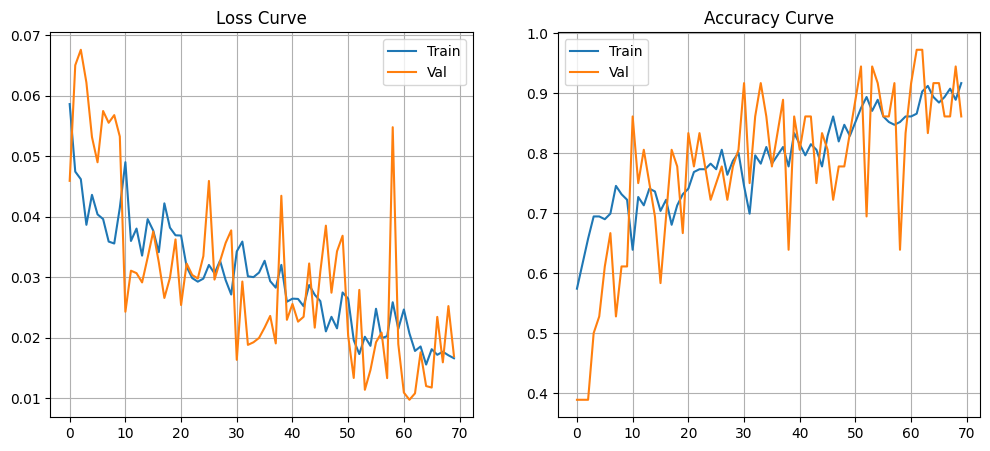

<All keys matched successfully>

In [19]:
def plot_curves(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid()

    plt.show()


plot_curves(train_losses, val_losses, train_accs, val_accs)

# Load best model and test
# model.load_state_dict(torch.load("best_model.pth"))
model.load_state_dict(
    torch.load(global_best_path, map_location=device),
    strict=True
)



Classification Report:
              precision    recall  f1-score   support

      benign       1.00      0.97      0.99        35
   malignant       0.96      1.00      0.98        22

    accuracy                           0.98        57
   macro avg       0.98      0.99      0.98        57
weighted avg       0.98      0.98      0.98        57



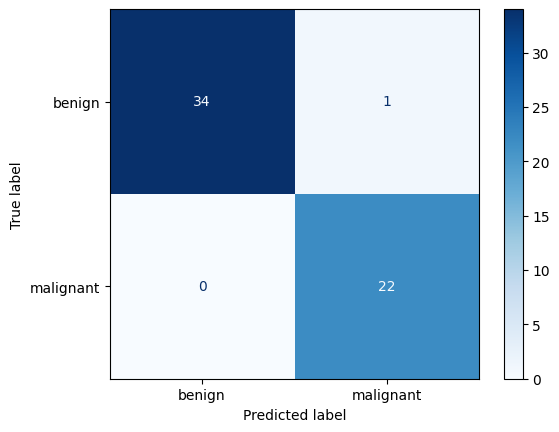

Test - Loss: 0.0089, Acc: 0.9825, Prec: 0.9832, Recall: 0.9825, F1: 0.9825


In [20]:
def test_model(model, loader, criterion, device, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)

            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    avg_loss = running_loss / len(loader.dataset)

    acc, prec, rec, f1, sens, spec = compute_metrics(all_labels, all_preds)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
    plt.show()

    return avg_loss, acc, prec, rec, f1, all_labels, all_preds, all_probs

test_loss, test_acc, test_prec, test_rec, test_f1, all_labels, all_preds, all_probs = test_model(
    model, test_loader, criterion, device, class_names
)
print(f"Test - Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Recall: {test_rec:.4f}, F1: {test_f1:.4f}")
    